In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
import plotly.graph_objects as go

from tqdm import tqdm

p_rad = 0.5
mtype = 'ico'
root = os.path.join('/home/mmccraw/dev/data/26-01-01/grant/friction-surface', mtype)

def load_data(root, nv):
    paths = np.array(os.listdir(os.path.join(root, str(nv))))
    arads = np.array([float(p.split('-')[3]) for p in paths])

    mus = []
    separations = []

    for arad in tqdm(np.unique(arads), total=len(np.unique(arads))):
        _mus = []
        _separations = []
        for path in paths[arads == arad]:
            data = np.load(os.path.join(root, str(nv), path))
            _mus.append(data['mu'])
            _separations.append(data['separation'])
        mus.append(np.concatenate(_mus))
        separations.append(np.concatenate(_separations))
    return {
        'mu': mus,
        'separation': separations,
        'arad': np.unique(arads)
    }

data_13 = load_data(root, 13)
data_43 = load_data(root, 43)
data_93 = load_data(root, 93)


100%|██████████| 100/100 [00:06<00:00, 15.87it/s]


# Single Particle Friction Measurements

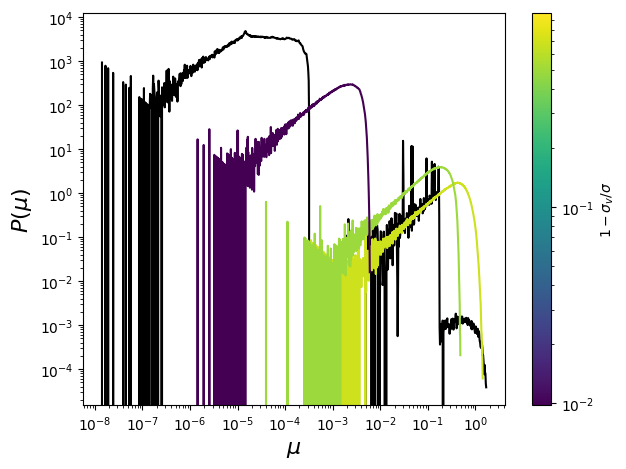

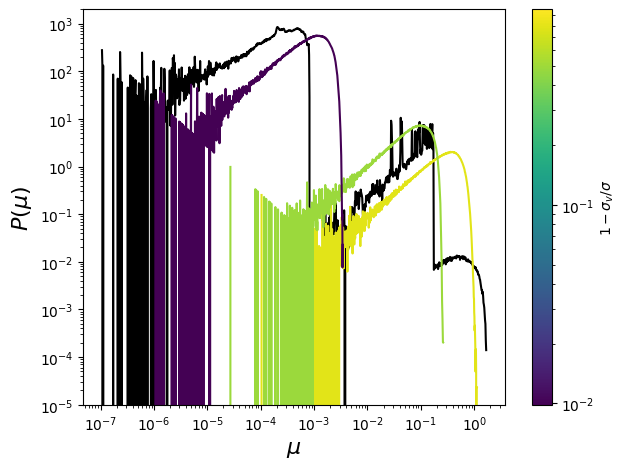

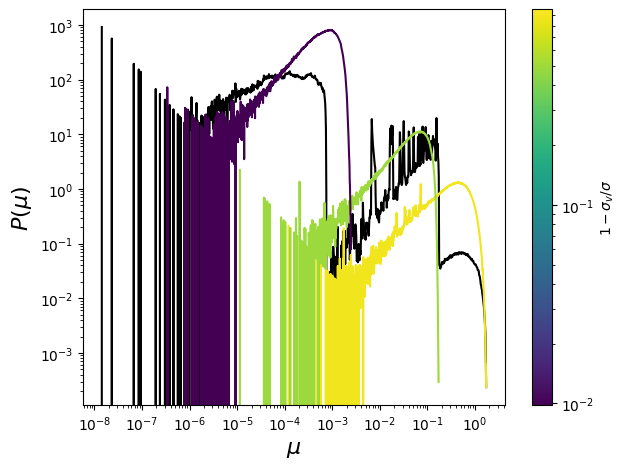

In [2]:
list_of_indices = [
    [1, 30, 50, 99],
    [1, 20, 50, 99],
    [1, 10, 50, 99],
]

for data, name, indices in zip([data_13, data_43, data_93], ['13', '43', '93'], list_of_indices):

    cmap = plt.cm.viridis
    arad_norm = LogNorm(min(1 - data['arad'][indices] / p_rad), max(1 - data['arad'][indices] / p_rad))
    # arad_norm = plt.Normalize(min(1 - data['arad'][indices] / p_rad), max(1 - data['arad'][indices] / p_rad))

    for i in indices:
        mu_vals = data['mu'][i]
        bins = np.logspace(
            np.log10(min(mu_vals[mu_vals > 0])),
            np.log10(max(mu_vals)),
            1_000,
        )
        p_mu, edges = np.histogram(mu_vals, bins=bins, density=True)
        mu = (edges[1:] + edges[:-1]) / 2.0
        if i == 1:
            c = 'k'
        else:
            c = cmap(arad_norm(2.0 * (p_rad - data['arad'][i])))
        plt.plot(mu, p_mu, c=c)

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel(r'$\mu$', fontsize=16)
    plt.ylabel(r'$P(\mu)$', fontsize=16)

    sm = plt.cm.ScalarMappable(norm=arad_norm, cmap=cmap)
    sm.set_array((1 - data['arad'][indices] / p_rad))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$1 - \sigma_v / \sigma$')

    plt.tight_layout()
    plt.savefig(f'new-figures/{mtype}-{name}-friction-distributions.png', dpi=600)
    plt.show()

0.08 0.5728791636429595
0.25 0.1108492473255949
0.35 0.052592397043402454
0.45 0.014858145545994022


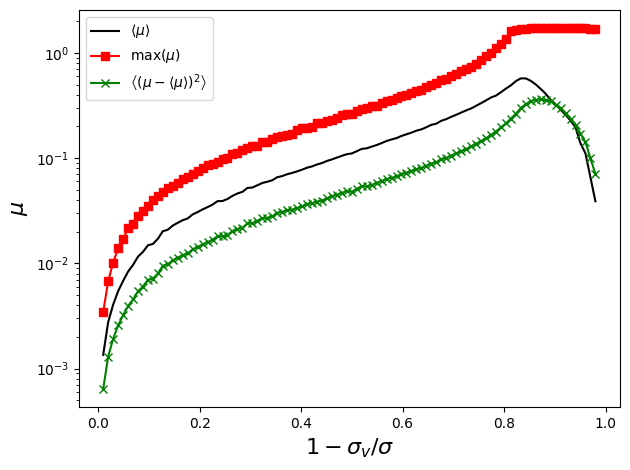

In [3]:
for data, name in zip([data_13, data_43, data_93], ['13', '43', '93']):
    if name != '43':
        continue

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    # x /= x[np.argmax(y_mean)]

    plt.plot(x, y_mean, c='k', label=r'$\langle \mu \rangle$')
    plt.plot(x, y_max, c='r', marker='s', label=r'$\max(\mu)$')
    plt.plot(x, y_std, c='g', marker='x', label=r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')
    # plt.axvline(1.0)

    plt.legend()
    plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
    plt.ylabel(r'$\mu$', fontsize=16)

    for r in [0.08, 0.25, 0.35, 0.45]:
        # plt.axvline((1 - r / p_rad))
        print(r, y_mean[np.argmin(abs(data['arad'] - r))])

    plt.yscale('log')
    
    plt.tight_layout()
    plt.savefig(f'new-figures/{mtype}-{name}-friction-curves.png', dpi=600)
    plt.show()

0.08 0.2823582289762846
0.25 0.2100573812742928
0.35 0.09720653183257555
0.45 0.02638336269943908


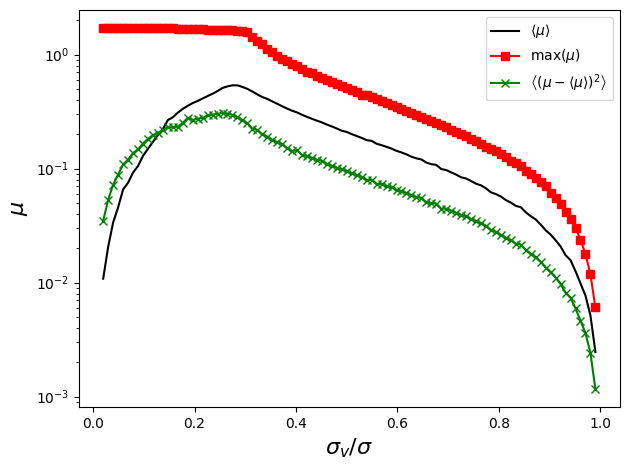

0.08 0.5728791636429595
0.25 0.1108492473255949
0.35 0.052592397043402454
0.45 0.014858145545994022


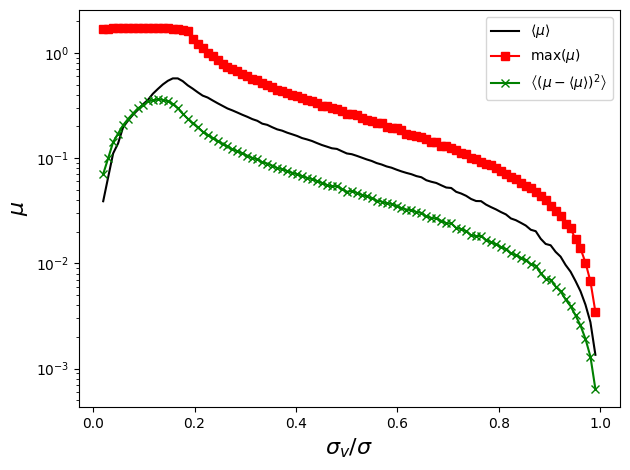

0.08 0.3826622854320381
0.25 0.07517747138307153
0.35 0.03642637645187412
0.45 0.009762686889401205


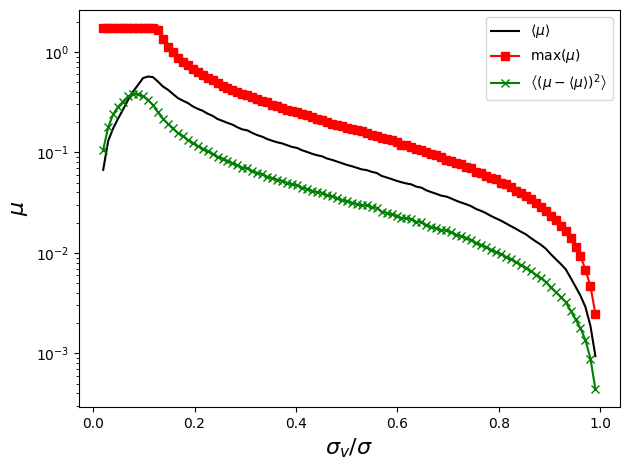

In [4]:
for data, name in zip([data_13, data_43, data_93], ['13', '43', '93']):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    # x /= x[np.argmax(y_mean)]

    plt.plot(x, y_mean, c='k', label=r'$\langle \mu \rangle$')
    plt.plot(x, y_max, c='r', marker='s', label=r'$\max(\mu)$')
    plt.plot(x, y_std, c='g', marker='x', label=r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')
    # plt.axvline(1.0)

    plt.legend()
    plt.xlabel(r'$\sigma_v / \sigma$', fontsize=16)
    plt.ylabel(r'$\mu$', fontsize=16)

    for r in [0.08, 0.25, 0.35, 0.45]:
        # plt.axvline((r / p_rad))
        print(r, y_mean[np.argmin(abs(data['arad'] - r))])

    plt.yscale('log')
    
    plt.tight_layout()
    plt.savefig(f'new-figures-reverse/{mtype}-{name}-friction-curves.png', dpi=600)
    plt.show()

### Mean

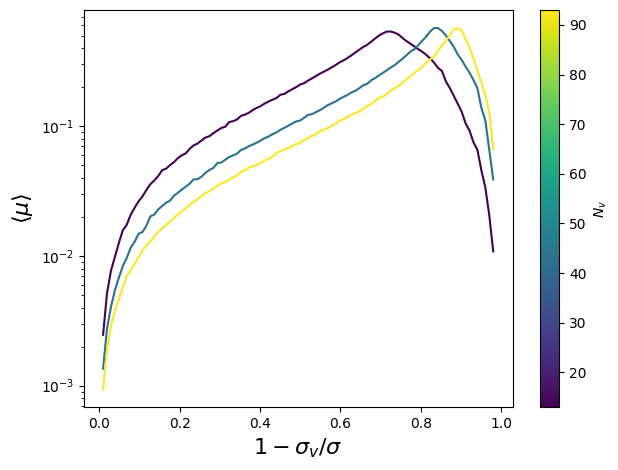

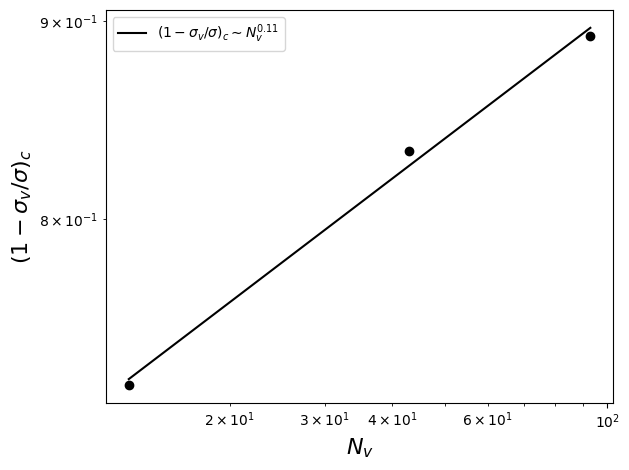

In [5]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_mean, c=cmap(nv_norm(nv)))

    xc.append(x[np.argmax(y_mean)])
    n.append(nv)

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-mean-friction.png', dpi=600)
plt.show()

plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(1 - \sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(1 - \sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-mean-friction-scaling.png')
plt.show()

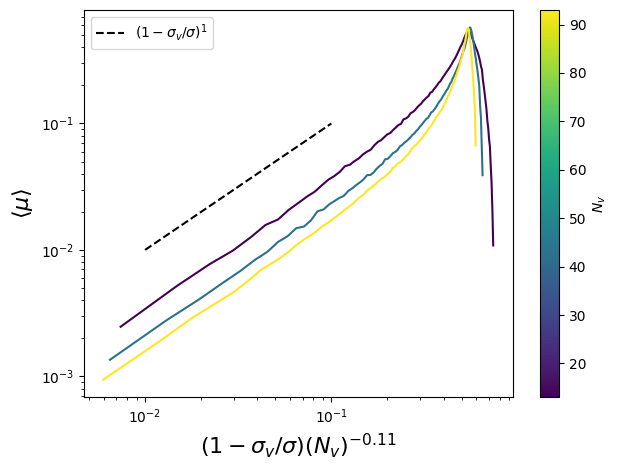

In [6]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x / (nv ** 0.11), y_mean, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(1 - \sigma_v / \sigma) (N_v)^{-0.11}$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

x = np.logspace(-2, -1)
plt.plot(x, x, ls='--', c='k', label=r'$(1 - \sigma_v / \sigma)^1$')
plt.legend()

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-scaled-mean-friction.png', dpi=600)
plt.show()

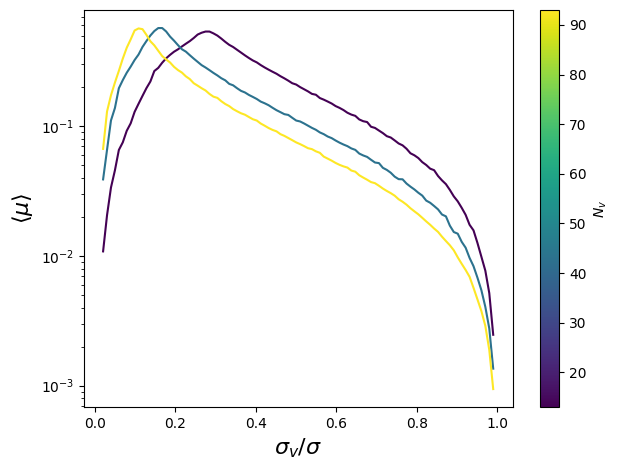

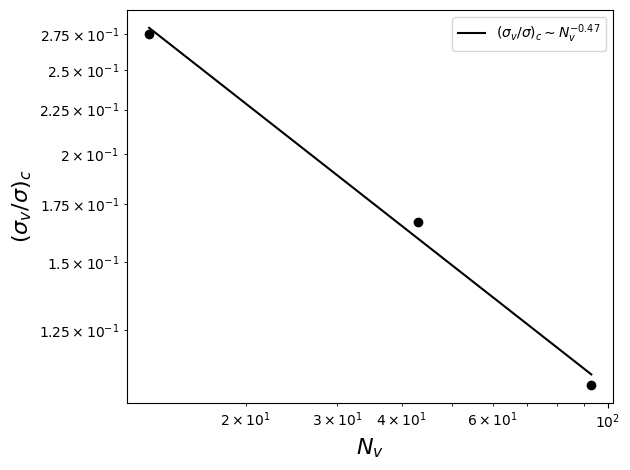

In [7]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_mean, c=cmap(nv_norm(nv)))

    xc.append(x[np.argmax(y_mean)])
    n.append(nv)

plt.xlabel(r'$\sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-mean-friction.png', dpi=600)
plt.show()

plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(\sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(\sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-mean-friction-scaling.png')
plt.show()

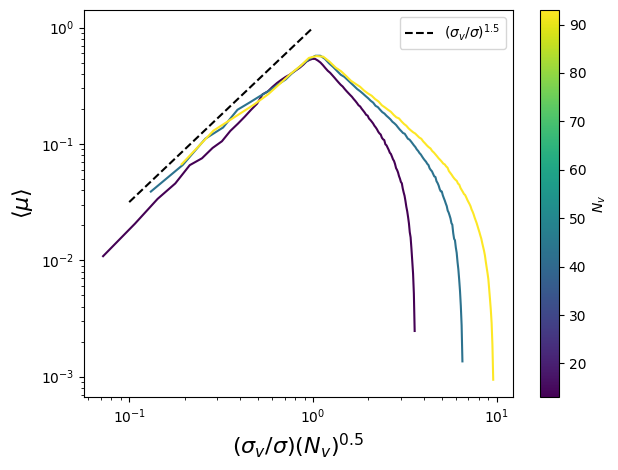

In [8]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x * (nv ** 0.5), y_mean, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(\sigma_v / \sigma) (N_v)^{0.5}$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

x = np.logspace(-1, 0)
plt.plot(x, x ** 1.5, ls='--', c='k', label=r'$(\sigma_v / \sigma)^{1.5}$')
plt.legend()

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-scaled-mean-friction.png', dpi=600)
plt.show()

### Max

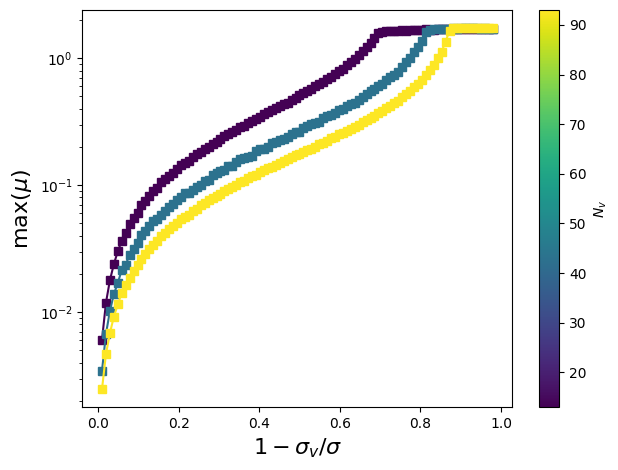

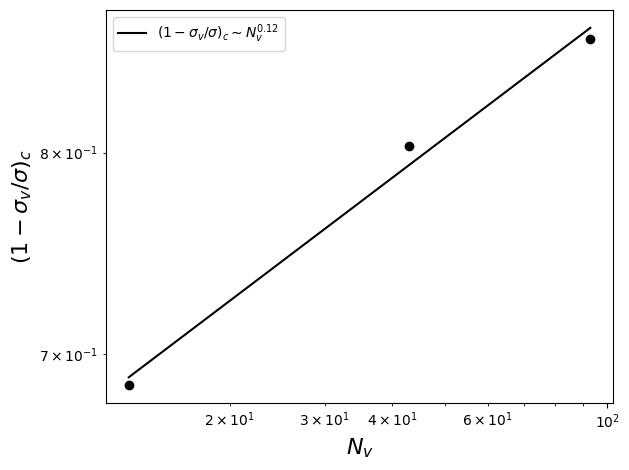

In [9]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_max, marker='s', c=cmap(nv_norm(nv)))
    
    xc.append(x[np.argmax(np.abs(np.diff(y_max))) + 1])
    n.append(nv)

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-max-friction.png', dpi=600)
plt.show()

plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(1 - \sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(1 - \sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-max-friction-scaling.png')
plt.show()

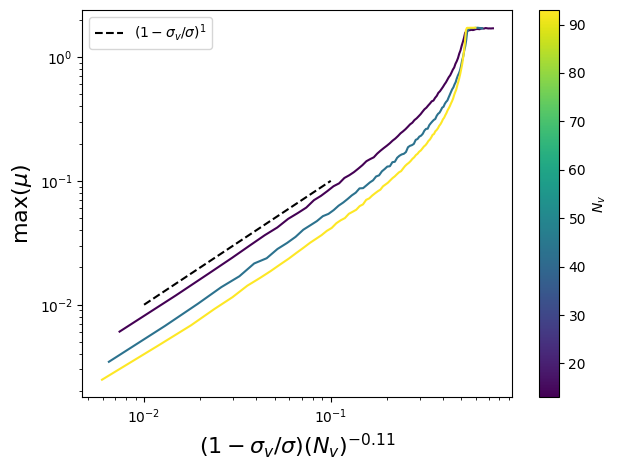

In [10]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x / (nv ** 0.11), y_max, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(1 - \sigma_v / \sigma) (N_v)^{-0.11}$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

x = np.logspace(-2, -1)
plt.plot(x, x, ls='--', c='k', label=r'$(1 - \sigma_v / \sigma)^1$')
plt.legend()

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-scaled-max-friction.png', dpi=600)
plt.show()

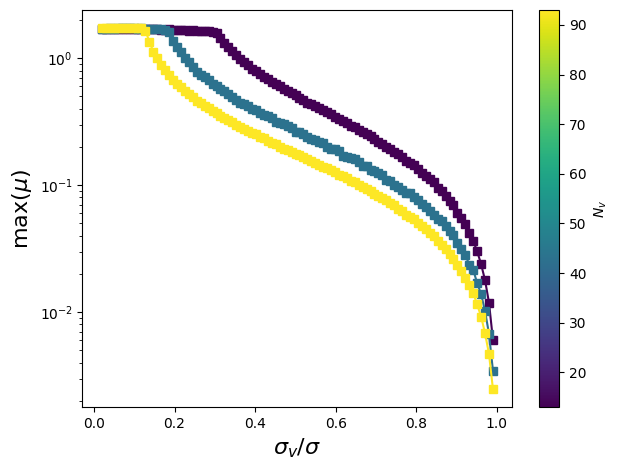

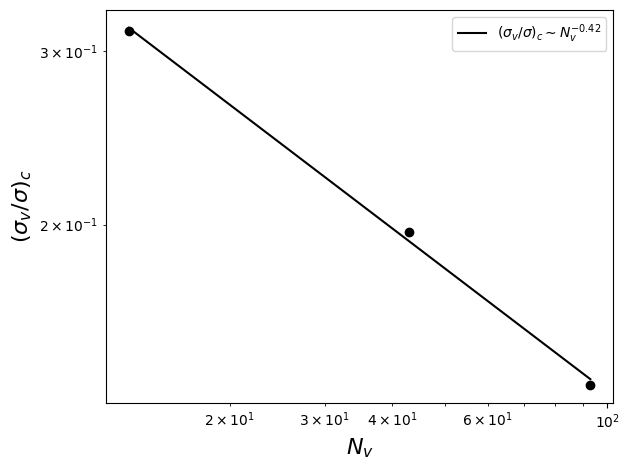

In [11]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_max, marker='s', c=cmap(nv_norm(nv)))
    
    xc.append(x[np.argmax(np.abs(np.diff(y_max))) + 1])
    n.append(nv)

plt.xlabel(r'$\sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-max-friction.png', dpi=600)
plt.show()

plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(\sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(\sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-max-friction-scaling.png')
plt.show()

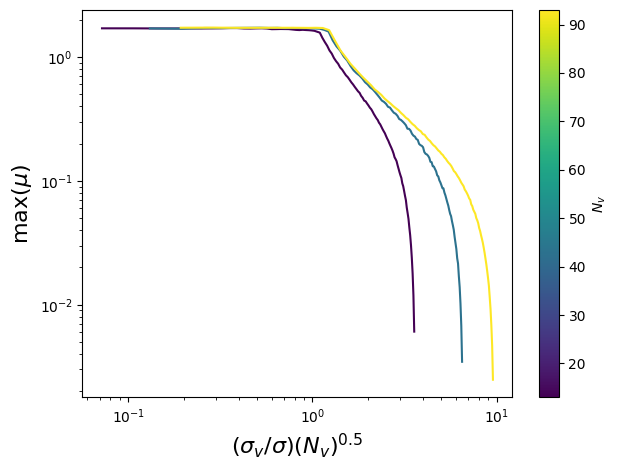

In [12]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x * (nv ** 0.5), y_max, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(\sigma_v / \sigma) (N_v)^{0.5}$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-scaled-max-friction.png', dpi=600)
plt.show()

### Std. Dev.

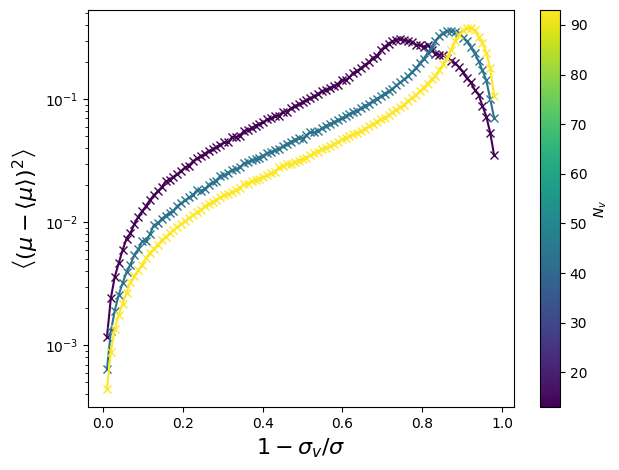

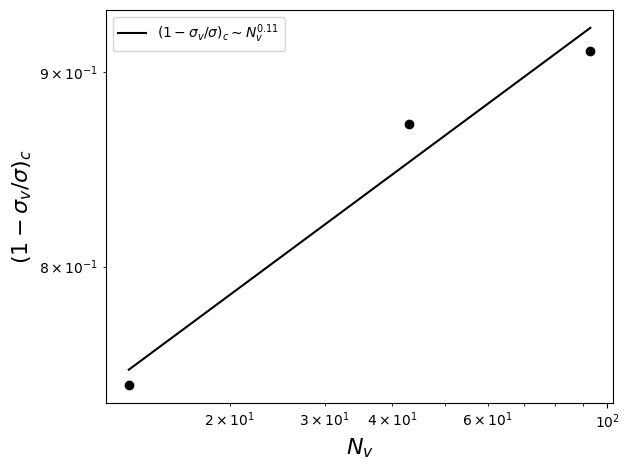

In [13]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_std, marker='x', c=cmap(nv_norm(nv)))

    xc.append(x[np.argmax(y_std)])
    n.append(nv)

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-std-friction.png', dpi=600)
plt.show()


plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(1 - \sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(1 - \sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-std-friction-scaling.png')
plt.show()

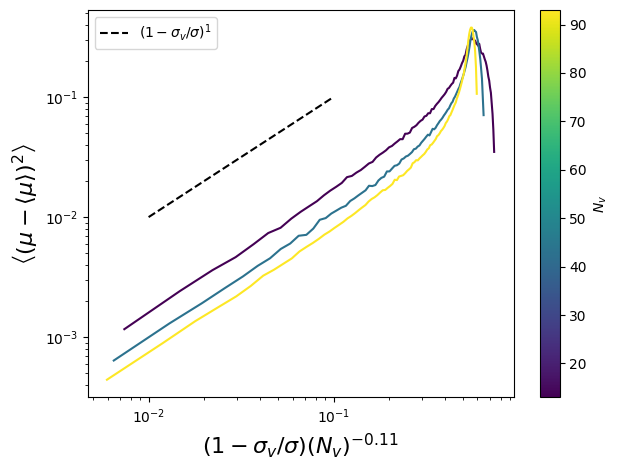

In [14]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x / (nv ** 0.11), y_std, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(1 - \sigma_v / \sigma) (N_v)^{-0.11}$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

x = np.logspace(-2, -1)
plt.plot(x, x, ls='--', c='k', label=r'$(1 - \sigma_v / \sigma)^1$')
plt.legend()

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-scaled-std-friction.png', dpi=600)
plt.show()

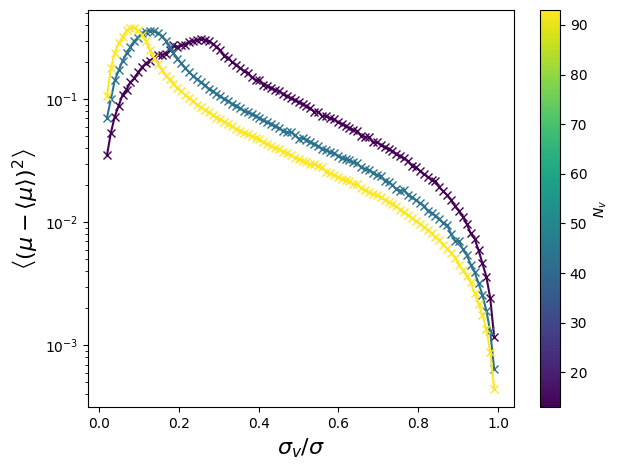

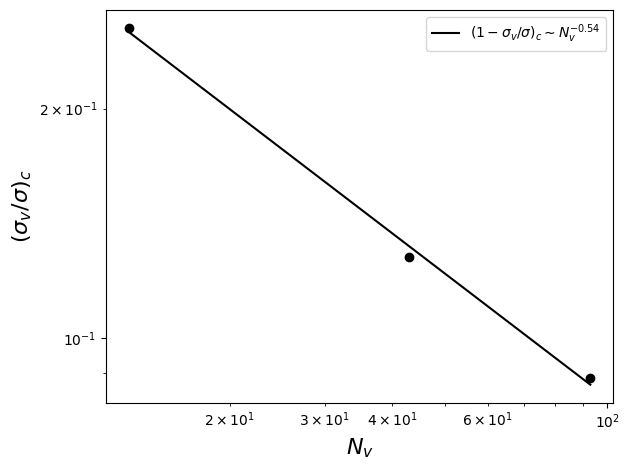

In [15]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

xc = []
n = []

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_std, marker='x', c=cmap(nv_norm(nv)))

    xc.append(x[np.argmax(y_std)])
    n.append(nv)

plt.xlabel(r'$\sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-std-friction.png', dpi=600)
plt.show()


plt.scatter(n, xc, c='k')
plt.xscale('log')
plt.yscale('log')
a, b = np.polyfit(np.log10(n), np.log10(xc), deg=1)
x = np.linspace(min(np.log10(n)), max(np.log10(n)), 10)
plt.plot(10 ** x, 10 ** (a * x + b), label=rf'$(1 - \sigma_v / \sigma)_c \sim N_v^{{{a:.2f}}}$', c='k')
plt.legend()
plt.xlabel(r'$N_v$', fontsize=16)
plt.ylabel(r'$(\sigma_v / \sigma)_c$', fontsize=16)
plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-std-friction-scaling.png')
plt.show()

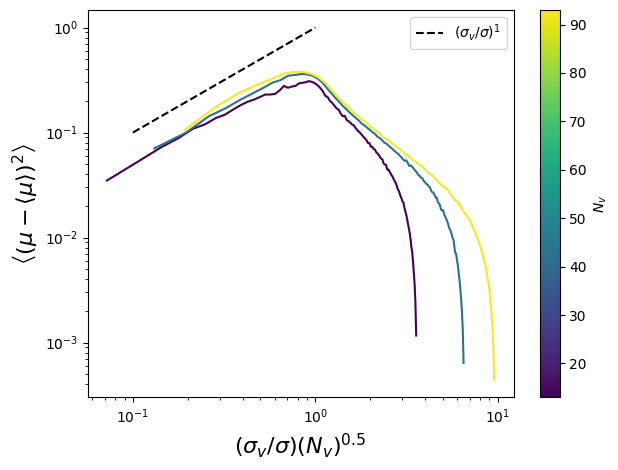

In [16]:
for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x * (nv ** 0.5), y_std, c=cmap(nv_norm(nv)))

plt.xlabel(r'$(\sigma_v / \sigma) (N_v)^{0.5}$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

x = np.logspace(-1, 0)
plt.plot(x, x, ls='--', c='k', label=r'$(\sigma_v / \sigma)^1$')
plt.legend()

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.savefig(f'new-figures-reverse/{mtype}-scaled-std-friction.png', dpi=600)
plt.show()

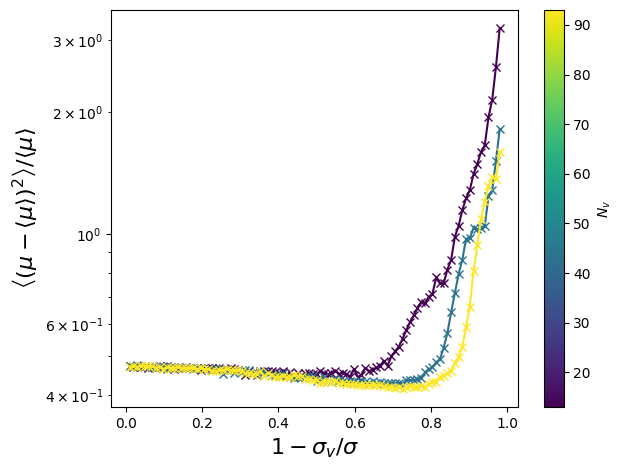

In [17]:
names = ['13', '43', '93']

nvs = [int(n) for n in names]

cmap = plt.cm.viridis
nv_norm = plt.Normalize(min(nvs), max(nvs))

for data, name, nv in zip([data_13, data_43, data_93], names, nvs):

    x = (1 - data['arad'] / p_rad)
    y_mean = np.array([np.mean(m) for m in data['mu']])
    y_max = np.array([np.max(m) for m in data['mu']])
    y_std = np.array([np.std(m) for m in data['mu']])
    
    plt.plot(x, y_std / y_mean, marker='x', c=cmap(nv_norm(nv)))

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle / \langle \mu \rangle$', fontsize=16)
plt.yscale('log')

sm = plt.cm.ScalarMappable(norm=nv_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$N_v$')

plt.tight_layout()
plt.savefig(f'new-figures/{mtype}-normstd-friction.png', dpi=600)
plt.show()

# Comparing to Friction in Jammed Configurations

In [23]:
def hist(val, bins=None, log=False):
    val = np.asarray(val)
    if bins is None:
        n = int(np.sqrt(len(val)))
        if log:
            bins = np.logspace(
                min(np.log10(val[val > 0])),
                max(np.log10(val[val > 0])),
                n
            )
        else:
            bins = np.linspace(
                min(val),
                max(val),
                n
            )
    p_val, edges = np.histogram(
        val,
        bins,
        density=True
    )
    return p_val, (edges[1:] + edges[:-1]) / 2

jam_friction_root = '/home/mmccraw/dev/analysis/spring-26/01/grant/analyzing-server-data/data'
mu_clump_large = np.load(os.path.join(jam_friction_root, 'mu_clump_large.npz'))
mu_vertex_large = np.load(os.path.join(jam_friction_root, 'mu_vertex_large.npz'))
mu_clump_large_with_core = np.load(os.path.join(jam_friction_root, 'mu_clump_large_with_core.npz'))

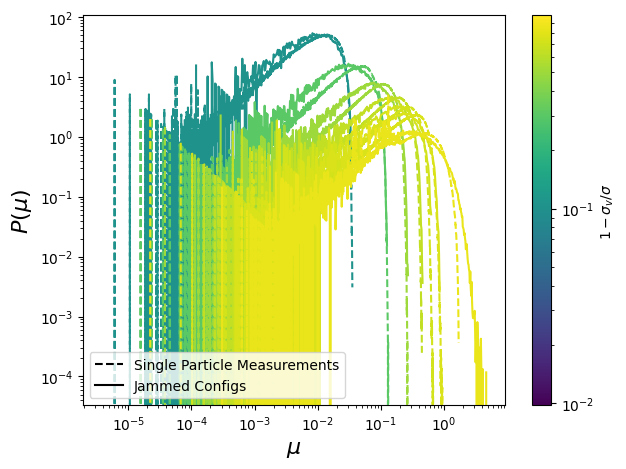

In [25]:
cmap = plt.cm.viridis
arad_norm = LogNorm(min(1 - np.unique(data_43['arad']) / p_rad), max(1 - np.unique(data_43['arad']) / p_rad))

ds = mu_clump_large
for arad in np.unique(ds['arad'])[::-1]:
    c = cmap(arad_norm(1 - arad / p_rad))

    i = np.argmin(np.abs(data_43['arad'] - arad))
    p_mu, mu = hist(data_43['mu'][i], log=True)
    plt.plot(mu, p_mu, c=c, ls='--')

    mask = ds['arad'] == arad
    p_mu, mu = hist(ds['val'][mask], log=True)
    plt.plot(mu, p_mu, c=c)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\mu$', fontsize=16)
plt.ylabel(r'$P(\mu)$', fontsize=16)

plt.plot([], [], label='Single Particle Measurements', ls='--', c='k')
plt.plot([], [], label='Jammed Configs', ls='-', c='k')
plt.legend()

sm = plt.cm.ScalarMappable(norm=arad_norm, cmap=cmap)
sm.set_array(nvs)
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$1 - \sigma_v / \sigma$')

plt.tight_layout()
plt.savefig('figures-compare-with-jamming/distributions_nv-43.png', dpi=600)
plt.show()

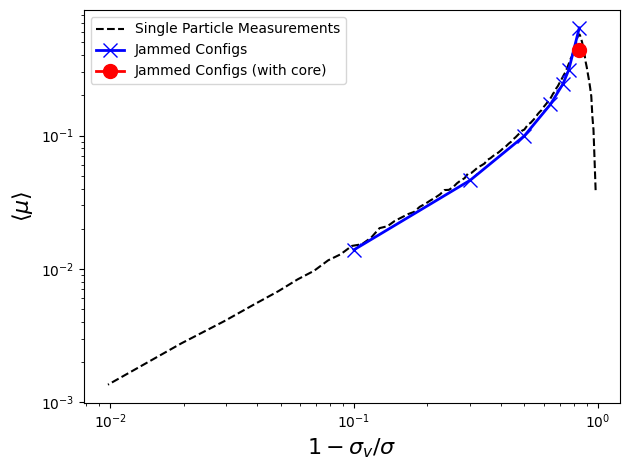

In [29]:
cmap = plt.cm.viridis
arad_norm = LogNorm(min(1 - np.unique(data_43['arad']) / p_rad), max(1 - np.unique(data_43['arad']) / p_rad))

plt.plot((1 - data_43['arad'] / p_rad), np.array([np.mean(m) for m in data_43['mu']]), ls='--', c='k', label='Single Particle Measurements')

ds = mu_clump_large
means = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    means.append(np.mean(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, means, marker='x', markersize=10, c='b', lw=2, label='Jammed Configs')



ds = mu_clump_large_with_core
means = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    means.append(np.mean(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, means, marker='o', markersize=5, c='r', lw=2, label='Jammed Configs (with core)')


# ds = mu_vertex_large
# means = []
# x = []
# for arad in np.unique(ds['arad'])[::-1]:
#     mask = ds['arad'] == arad
#     means.append(np.mean(ds['val'][mask]))
#     x.append(1 - arad / p_rad)
# plt.plot(x, means, marker='x', markersize=10, c='r', lw=2, label='Jammed Configs')

plt.legend()

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\langle \mu \rangle$', fontsize=16)

plt.tight_layout()
plt.savefig('figures-compare-with-jamming/mean_nv-43.png', dpi=600)
plt.show()

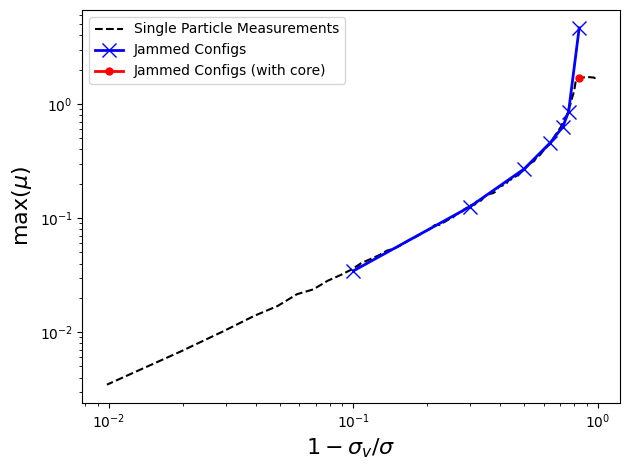

In [34]:
cmap = plt.cm.viridis
arad_norm = LogNorm(min(1 - np.unique(data_43['arad']) / p_rad), max(1 - np.unique(data_43['arad']) / p_rad))

plt.plot((1 - data_43['arad'] / p_rad), np.array([np.max(m) for m in data_43['mu']]), ls='--', c='k', label='Single Particle Measurements')

ds = mu_clump_large
maxs = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    maxs.append(np.max(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, maxs, marker='x', markersize=10, c='b', lw=2, label='Jammed Configs')



ds = mu_clump_large_with_core
maxs = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    maxs.append(np.max(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, maxs, marker='o', markersize=5, c='r', lw=2, label='Jammed Configs (with core)')



# ds = mu_vertex_large
# maxs = []
# x = []
# for arad in np.unique(ds['arad'])[::-1]:
#     mask = ds['arad'] == arad
#     maxs.append(np.max(ds['val'][mask]))
#     x.append(1 - arad / p_rad)
# plt.plot(x, maxs, marker='x', markersize=10, c='r', lw=2, label='Jammed Configs')

plt.legend()

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\max(\mu)$', fontsize=16)

plt.tight_layout()
plt.savefig('figures-compare-with-jamming/max_nv-43.png', dpi=600)
plt.show()

In [ ]:
cmap = plt.cm.viridis
arad_norm = LogNorm(min(1 - np.unique(data_43['arad']) / p_rad), max(1 - np.unique(data_43['arad']) / p_rad))

plt.plot((1 - data_43['arad'] / p_rad), np.array([np.std(m) for m in data_43['mu']]), ls='--', c='k', label='Single Particle Measurements')

ds = mu_clump_large
stds = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    stds.append(np.std(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, stds, marker='x', markersize=10, c='b', lw=2, label='Jammed Configs')



ds = mu_clump_large_with_core
stds = []
x = []
for arad in np.unique(ds['arad'])[::-1]:
    mask = ds['arad'] == arad
    stds.append(np.std(ds['val'][mask]))
    x.append(1 - arad / p_rad)
plt.plot(x, stds, marker='o', markersize=5, c='r', lw=2, label='Jammed Configs (with core)')



# ds = mu_vertex_large
# stds = []
# x = []
# for arad in np.unique(ds['arad'])[::-1]:
#     mask = ds['arad'] == arad
#     stds.append(np.std(ds['val'][mask]))
#     x.append(1 - arad / p_rad)
# plt.plot(x, stds, marker='x', markersize=10, c='r', lw=2, label='Jammed Configs')

plt.legend()

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$1 - \sigma_v / \sigma$', fontsize=16)
plt.ylabel(r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$', fontsize=16)

plt.tight_layout()
plt.savefig('figures-compare-with-jamming/std_nv-43.png', dpi=600)
plt.show()

# Rendering the Friction on the Surface

In [147]:
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/93/nv-93-arad-0.1031-theta-0.0000-phi-0.0000.npz"
root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/93/nv-93-arad-0.07369999999999999-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.07369999999999999-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.1031-theta-0.0000-phi-0.1745.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.01-theta-0.0000-phi-0.0000.npz"
# root = "/home/mmccraw/dev/data/26-01-01/grant/friction-surface/ico/13/nv-13-arad-0.01-theta-0.0000-phi-0.1745.npz"
data = np.load(root)
# plt.scatter(data['theta'], data['phi'], c=data['separation'], s=0.05)
# mu = data['mu']
# plt.hist(mu)


In [148]:
from scipy.spatial import ConvexHull

X = np.sin(data['theta']) * np.cos(data['phi'])
Y = np.sin(data['theta']) * np.sin(data['phi'])
Z = np.cos(data['theta'])

# triangulate the points on the sphere via their convex hull
hull = ConvexHull(np.column_stack([X, Y, Z]))

fig = go.Figure(
    go.Mesh3d(
        x=X, y=Y, z=Z,
        i=hull.simplices[:, 0],
        j=hull.simplices[:, 1],
        k=hull.simplices[:, 2],
        intensity=data['mu'],
        colorscale="Viridis",
        colorbar=dict(title="μ"),
    )
)
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_30859/3065664786.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(p_rad - rad, np.mean(data['mu']), c=cmap(nv_norm(nv)))
/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_30859/3065664786.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(p_rad - rad, np.std(data['mu']), c=cmap(nv_norm(nv)))


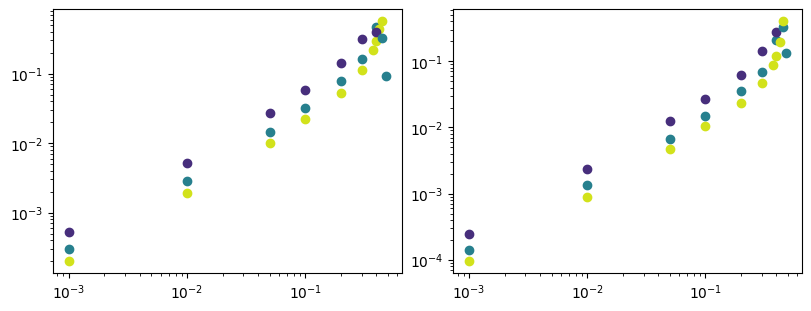

In [ ]:
p_rad = 0.5

nv_norm = plt.Normalize(0, 100)
cmap = plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

for path in os.listdir('results'):
    data = np.load(os.path.join('results', path))
    
    _, nv, _, rad = path.split('.npz')[0].split('-')
    nv = int(nv)
    rad = float(rad)

    ax[0].scatter(p_rad - rad, np.mean(data['mu']), c=cmap(nv_norm(nv)))
    ax[1].scatter(p_rad - rad, np.std(data['mu']), c=cmap(nv_norm(nv)))

for a in ax:
    a.set_xscale('log')
    a.set_yscale('log')

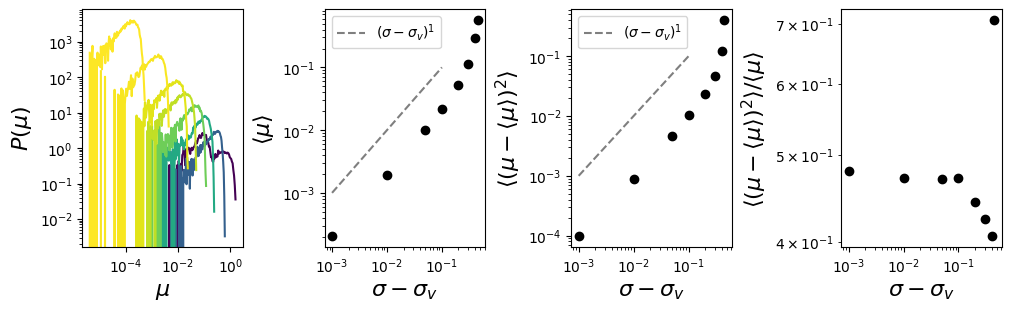

In [ ]:
p_rad = 0.5
# nv = 13
# nv = 43
nv = 93

paths = np.array([p if str(nv) in p else None for p in os.listdir('results')])
paths = paths[[p is not None for p in paths]]
rad = [float(p.split('.npz')[0].split('-')[-1]) for p in paths]
paths = np.array(paths)[np.argsort(rad)]
rad = np.sort(rad)

rad_norm = LogNorm(min(rad), max(rad))
cm = plt.cm.viridis

fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)

for p, r in zip(paths, rad):
    data = np.load(os.path.join('results', p))
    
    mu = data['mu']

    mu_bins = np.logspace(
        np.log10(min(mu)),
        np.log10(max(mu)),
        int(np.sqrt(mu.size))
    )

    p_mu, mu_edge = np.histogram(
        mu,
        mu_bins,
        density=True
    )
    mu_ax = (mu_edge[1:] + mu_edge[:-1]) / 2

    ax[0].plot(mu_ax, p_mu, color=cm(rad_norm(r)))
    ax[1].scatter(p_rad - r, np.mean(mu), c='k')
    ax[2].scatter(p_rad - r, np.std(mu), c='k')
    ax[3].scatter(p_rad - r, np.std(mu) / np.mean(mu), c='k')

x = np.logspace(-3, -1)
ax[1].plot(x, x, color='k', ls='--', zorder=0, alpha=0.5, label=r'$(\sigma - \sigma_v)^1$')
ax[2].plot(x, x, color='k', ls='--', zorder=0, alpha=0.5, label=r'$(\sigma - \sigma_v)^1$')

for a in ax:
    a.set_xscale('log')
    a.set_yscale('log')
ax[0].set_xlabel(r'$\mu$', fontsize=16)
ax[0].set_ylabel(r'$P(\mu)$', fontsize=16)
for a in ax[1:]:
    a.set_xlabel(r'$\sigma - \sigma_v$', fontsize=16)
for a in ax[1:3]:
    a.legend()
ax[1].set_ylabel(r'$\langle \mu \rangle$', fontsize=16)
ax[2].set_ylabel(r'$\langle (\mu  - \langle \mu \rangle)^2 \rangle$', fontsize=16)
ax[3].set_ylabel(r'$\langle (\mu  - \langle \mu \rangle)^2 \rangle / \langle \mu \rangle$', fontsize=16)

plt.savefig(f'figures/results-{nv}.png', dpi=600)